###Import libraries

Loads the Python tools the project needs: pandas for tables, NumPy for math, Matplotlib and Seaborn for charts, scikit-learn for models. It also fixes a random seed.

Everything later depends on these tools, and the fixed seed makes your results repeatable.

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.base import clone
from sklearn.calibration import calibration_curve
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (ConfusionMatrixDisplay, PrecisionRecallDisplay, RocCurveDisplay,
                             average_precision_score, classification_report, f1_score,
                             precision_recall_curve, precision_score, recall_score, roc_auc_score)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

###Load the dataset

Reads the weatherAUS CSV into a table (a DataFrame) and converts the Date column to real dates.
This is the raw material for the whole project.

In [4]:
df = pd.read_csv("https://rattle.togaware.com/weatherAUS.csv")
df["Date"] = pd.to_datetime(df["Date"])
print("Shape:", df.shape)
df.head()

Shape: (275410, 24)


,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RISK_MM,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,0.0,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,0.0,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,0.0,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,1.0,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,0.2,No


###Explore missing values and class balance

Checks missing values and class balance (how many rainy versus dry days), with charts.

In [5]:
missing = (df.isna().mean() * 100).sort_values(ascending=False)
print("Missing values (%):")
print(missing[missing > 0].round(1))

print("\nClass balance:")
print(df["RainTomorrow"].value_counts(normalize=True).round(3))

Missing values (%):
Sunshine         62.1
Evaporation      58.1
Cloud3pm         48.2
Cloud9am         45.9
Pressure9am      11.0
Pressure3pm      11.0
WindDir9am        7.8
WindGustDir       7.4
WindGustSpeed     7.4
WindDir3pm        4.5
Humidity3pm       4.2
WindSpeed3pm      3.9
Temp3pm           3.6
Rainfall          2.9
RainToday         2.9
RISK_MM           2.9
RainTomorrow      2.9
Humidity9am       2.3
WindSpeed9am      2.2
MinTemp           1.7
Temp9am           1.7
MaxTemp           1.7
dtype: float64

Class balance:
RainTomorrow
No     0.78
Yes    0.22
Name: proportion, dtype: float64


###charts

It shows what problems the data has before you build anything.

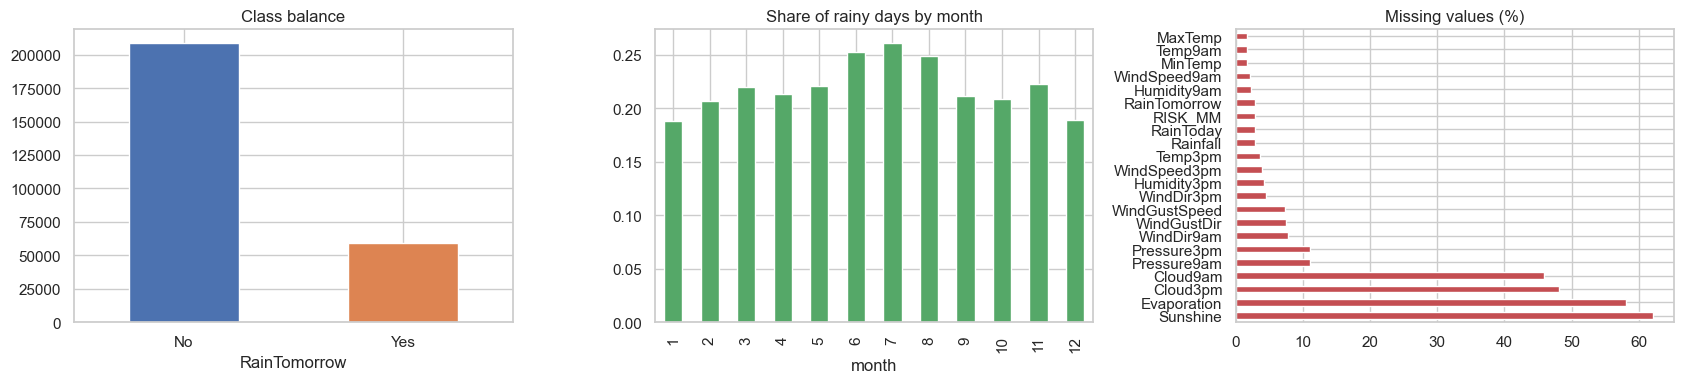

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4))

df["RainTomorrow"].value_counts().plot(kind="bar", ax=axes[0], color=["#4C72B0", "#DD8452"])
axes[0].set_title("Class balance")
axes[0].tick_params(axis="x", rotation=0)

monthly = (df.dropna(subset=["RainTomorrow"])
             .assign(rain=lambda d: (d["RainTomorrow"] == "Yes").astype(int),
                     month=lambda d: d["Date"].dt.month)
             .groupby("month")["rain"].mean())
monthly.plot(kind="bar", ax=axes[1], color="#55A868")
axes[1].set_title("Share of rainy days by month")

missing[missing > 0].plot(kind="barh", ax=axes[2], color="#C44E52")
axes[2].set_title("Missing values (%)")

plt.tight_layout()
plt.show()

###Clean the data and build the target

Removes the leaky RISK_MM column and rows with no answer, and converts RainTomorrow from Yes/No to 1/0.
The model needs a clean numeric target, and leaked columns would give fake, too-good results.

In [7]:
df = df.drop(columns=["RISK_MM"], errors="ignore")
df = df.dropna(subset=["RainTomorrow"]).copy()
df["RainTomorrow"] = (df["RainTomorrow"] == "Yes").astype(int)
print(df["RainTomorrow"].value_counts(normalize=True).round(3))

RainTomorrow
0    0.78
1    0.22
Name: proportion, dtype: float64


###Feature engineering

Creates new columns such as temperature range, pressure change, yesterday's rainfall, and 3-day and 7-day rain totals.

Well-chosen features often improve a model more than a fancier algorithm does.

In [8]:
df = df.sort_values(["Location", "Date"]).reset_index(drop=True)
g = df.groupby("Location")

df["Month"] = df["Date"].dt.month
df["TempRange"] = df["MaxTemp"] - df["MinTemp"]
df["PressureChange"] = df["Pressure3pm"] - df["Pressure9am"]
df["HumidityChange"] = df["Humidity3pm"] - df["Humidity9am"]
df["TempChange"] = df["Temp3pm"] - df["Temp9am"]

df["Rainfall_lag1"] = g["Rainfall"].shift(1)
df["Humidity3pm_lag1"] = g["Humidity3pm"].shift(1)
df["Pressure3pm_lag1"] = g["Pressure3pm"].shift(1)
df["Rainfall_3day"] = g["Rainfall"].transform(lambda s: s.rolling(3, min_periods=1).sum())
df["Rainfall_7day"] = g["Rainfall"].transform(lambda s: s.rolling(7, min_periods=1).sum())

df["Month_sin"] = np.sin(2 * np.pi * df["Month"] / 12)
df["Month_cos"] = np.cos(2 * np.pi * df["Month"] / 12)

print("Shape after feature engineering:", df.shape)

Shape after feature engineering: (267317, 35)


###Feature distributions

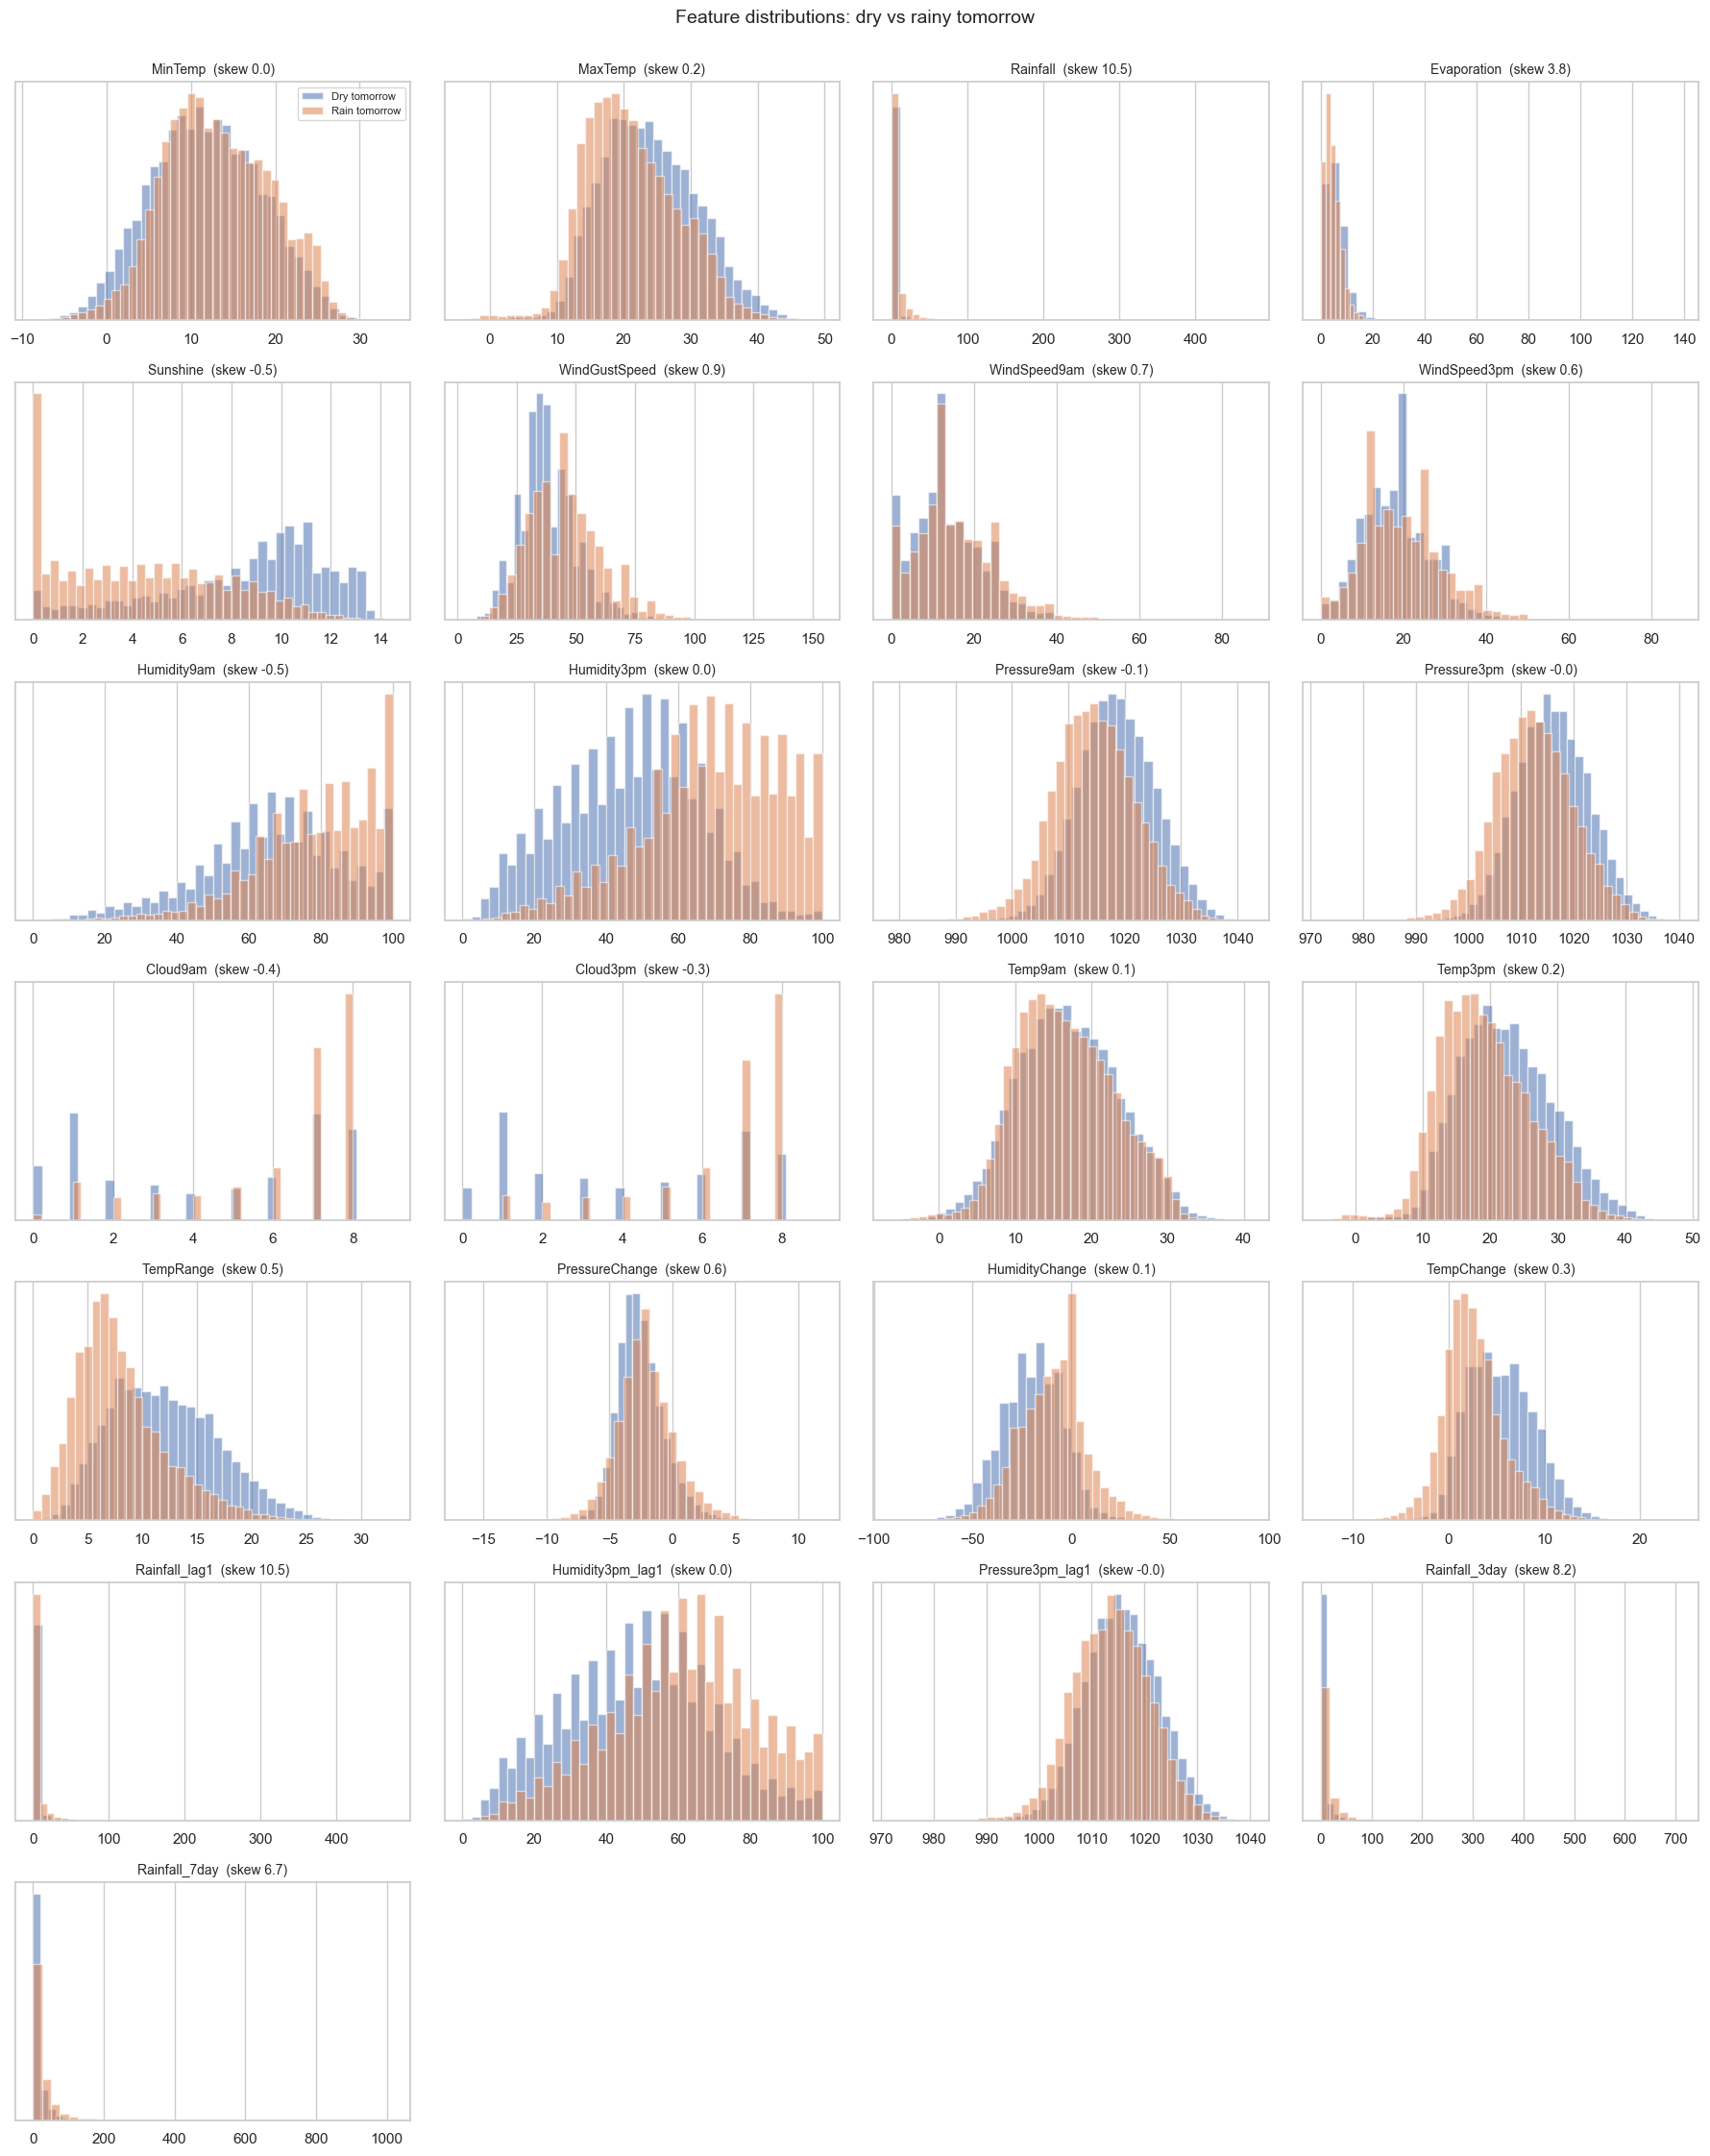

In [9]:
num_features = [c for c in df.select_dtypes(include="number").columns
                if c not in ("RainTomorrow", "Month", "Month_sin", "Month_cos")]

n_cols = 4
n_rows = int(np.ceil(len(num_features) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 3.2 * n_rows))
axes = axes.ravel()

for ax, col in zip(axes, num_features):
    for label, color, name in [(0, "#4C72B0", "Dry tomorrow"), (1, "#DD8452", "Rain tomorrow")]:
        vals = df.loc[df["RainTomorrow"] == label, col].dropna()
        ax.hist(vals, bins=40, alpha=0.55, color=color, density=True, label=name)
    ax.set_title(f"{col}  (skew {df[col].skew():.1f})", fontsize=10)
    ax.set_yticks([])

for ax in axes[len(num_features):]:
    ax.axis("off")

axes[0].legend(fontsize=8)
plt.suptitle("Feature distributions: dry vs rainy tomorrow", y=1.001, fontsize=14)
plt.tight_layout()
plt.show()

###Rainfall skew

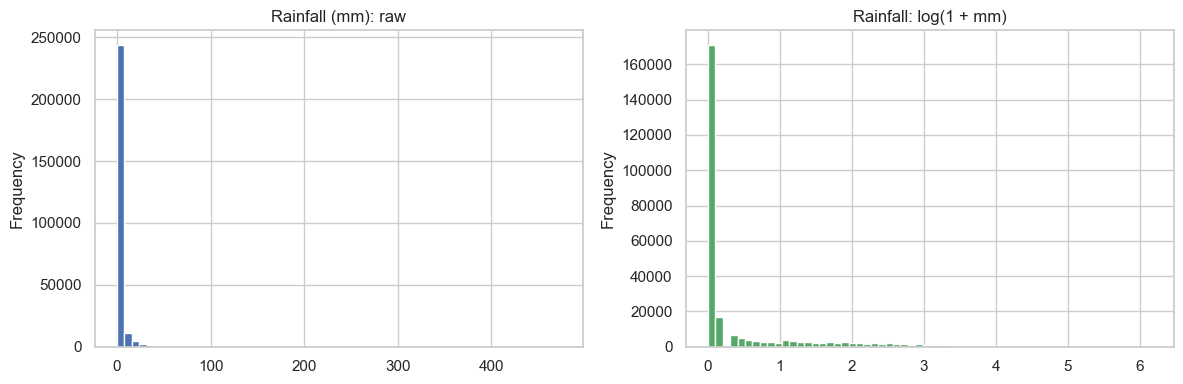

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df["Rainfall"].plot(kind="hist", bins=60, ax=axes[0], color="#4C72B0")
axes[0].set_title("Rainfall (mm): raw")
np.log1p(df["Rainfall"].dropna()).plot(kind="hist", bins=60, ax=axes[1], color="#55A868")
axes[1].set_title("Rainfall: log(1 + mm)")
plt.tight_layout()
plt.show()

###Outliers

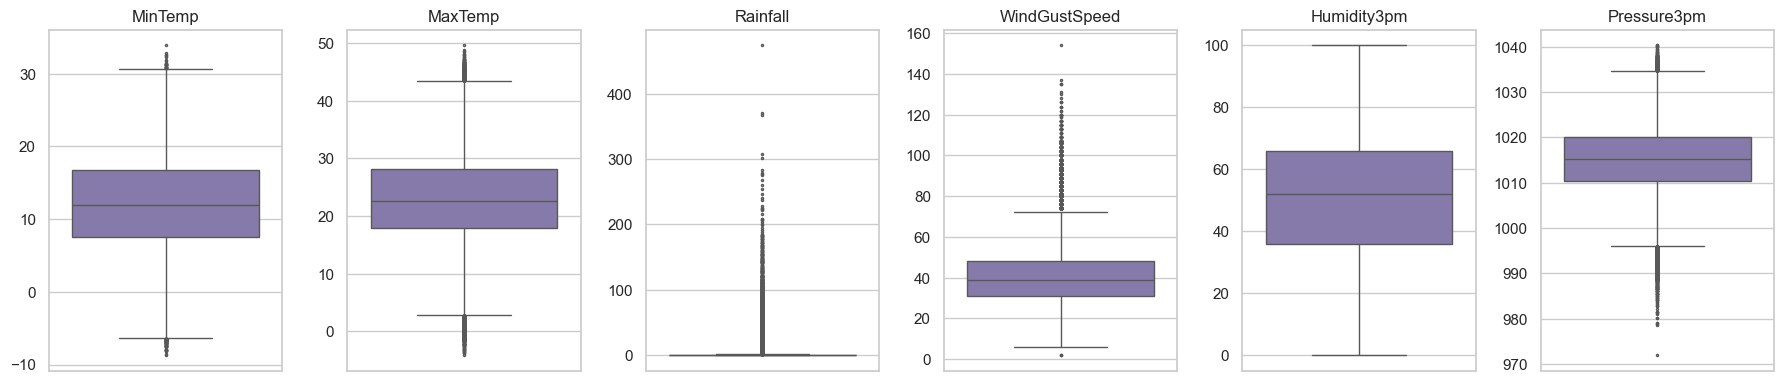

In [11]:
key = ["MinTemp", "MaxTemp", "Rainfall", "WindGustSpeed", "Humidity3pm", "Pressure3pm"]
fig, axes = plt.subplots(1, len(key), figsize=(18, 4))
for ax, col in zip(axes, key):
    sns.boxplot(y=df[col], ax=ax, color="#8172B2", fliersize=1.5)
    ax.set_title(col)
    ax.set_ylabel("")
plt.tight_layout()
plt.show()

###Correlation analysis

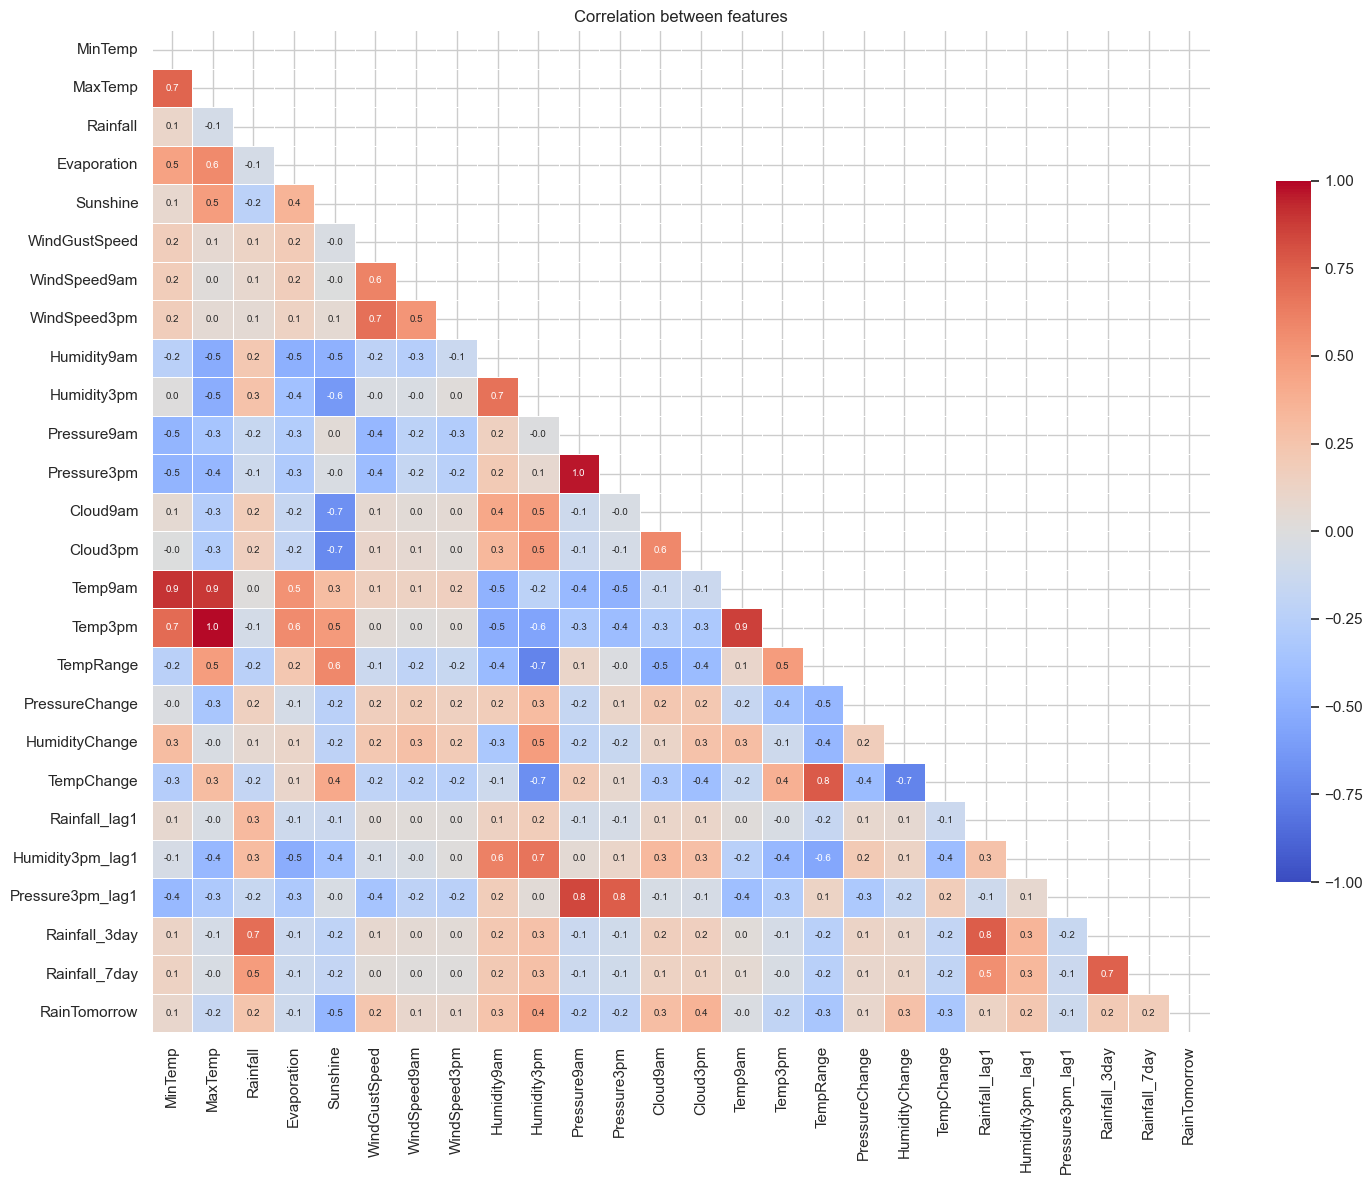

In [12]:
corr_cols = num_features + ["RainTomorrow"]
corr = df[corr_cols].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))
plt.figure(figsize=(15, 12))
sns.heatmap(corr, mask=mask, cmap="coolwarm", center=0, vmin=-1, vmax=1,
            annot=True, fmt=".1f", annot_kws={"size": 7},
            linewidths=0.4, cbar_kws={"shrink": 0.7})
plt.title("Correlation between features")
plt.tight_layout()
plt.show()

###Near-duplicate features

In [13]:
pairs = (corr.where(np.triu(np.ones(corr.shape, dtype=bool), k=1))
             .stack().rename("corr").reset_index())
pairs.columns = ["feature_1", "feature_2", "corr"]
strong = pairs[pairs["corr"].abs() >= 0.8].sort_values("corr", key=abs, ascending=False)
print(f"Highly correlated pairs (|r| >= 0.8): {len(strong)}")
strong.round(2).head(15)

Highly correlated pairs (|r| >= 0.8): 6


,feature_1,feature_2,corr
38,MaxTemp,Temp3pm,0.98
205,Pressure9am,Pressure3pm,0.96
13,MinTemp,Temp9am,0.90
37,MaxTemp,Temp9am,0.89
259,Temp9am,Temp3pm,0.86
216,Pressure9am,Pressure3pm_lag1,0.84


###Time-based train/test split

Train 22.3%: in the study set (2007 to 2022), about 22 out of every 100 days had rain the next day.
Test 21.1%: in the exam set (2022 to 2026), about 21 out of every 100 days had rain the next day.

In [14]:
df = df.sort_values("Date").reset_index(drop=True)
cutoff = df["Date"].quantile(0.8)
train = df[df["Date"] <= cutoff]
test = df[df["Date"] > cutoff]

X_cols = [c for c in df.columns if c not in ("Date", "RainTomorrow", "Month")]
Xtr, ytr = train[X_cols], train["RainTomorrow"]
Xte, yte = test[X_cols], test["RainTomorrow"]

print(f"Train: {train['Date'].min().date()} to {train['Date'].max().date()}  ({len(train):,} rows)")
print(f"Test:  {test['Date'].min().date()} to {test['Date'].max().date()}  ({len(test):,} rows)")
print(f"Rainy days: train {ytr.mean():.1%}, test {yte.mean():.1%}")

Train: 2007-11-01 to 2022-11-06  (213,863 rows)
Test:  2022-11-07 to 2026-01-30  (53,454 rows)
Rainy days: train 22.3%, test 21.1%


###Preprocessing pipeline

In [15]:
cat_cols = Xtr.select_dtypes(exclude="number").columns.tolist()
num_cols = [c for c in X_cols if c not in cat_cols]
print("Categorical:", cat_cols)
print("Numeric:", len(num_cols), "columns")

prep = ColumnTransformer(
    [
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median")),
                          ("scaler", StandardScaler())]), num_cols),
        ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")),
                          ("onehot", OneHotEncoder(handle_unknown="ignore",
                                                   sparse_output=False))]), cat_cols),
    ],
    sparse_threshold=0,
)

# Should print <class 'numpy.ndarray'>
print(type(prep.fit_transform(Xtr.head(2000))))

Categorical: ['Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainToday']
Numeric: 27 columns
<class 'numpy.ndarray'>


###Train and compare models

In [16]:
models = {
    "Baseline (always dry)": DummyClassifier(strategy="most_frequent"),
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=14, min_samples_leaf=5,
                                            class_weight="balanced", n_jobs=-1,
                                            random_state=RANDOM_STATE),
    "Gradient Boosting": HistGradientBoostingClassifier(class_weight="balanced",
                                                        random_state=RANDOM_STATE),
}

fitted, rows = {}, []
for name, model in models.items():
    pipe = Pipeline([("prep", prep), ("model", model)]).fit(Xtr, ytr)
    pred = pipe.predict(Xte)
    proba = pipe.predict_proba(Xte)[:, 1]
    fitted[name] = pipe
    rows.append({
        "Model": name,
        "Accuracy": (pred == yte).mean(),
        "Precision": precision_score(yte, pred, zero_division=0),
        "Recall": recall_score(yte, pred, zero_division=0),
        "F1": f1_score(yte, pred, zero_division=0),
        "ROC-AUC": roc_auc_score(yte, proba),
        "PR-AUC": average_precision_score(yte, proba),
    })

results = pd.DataFrame(rows).set_index("Model").round(3)
results.sort_values("ROC-AUC", ascending=False)

,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
Model,,,,,,
Gradient Boosting,0.811,0.534,0.790,0.637,0.890,0.730
Random Forest,0.820,0.556,0.722,0.628,0.873,0.699
Logistic Regression,0.797,0.512,0.766,0.614,0.872,0.689
Baseline (always dry),0.789,0.000,0.000,0.000,0.500,0.211


###Evaluate the best model

Draws the confusion matrices, ROC curve, precision-recall curve, probability histogram and calibration curve for the winner.It shows where the model is right, where it fails, and whether its probabilities can be trusted.

Best model: Gradient Boosting

               precision    recall  f1-score   support

         Dry      0.936     0.816     0.872     42197
        Rain      0.534     0.790     0.637     11257

    accuracy                          0.811     53454
   macro avg      0.735     0.803     0.755     53454
weighted avg      0.851     0.811     0.823     53454



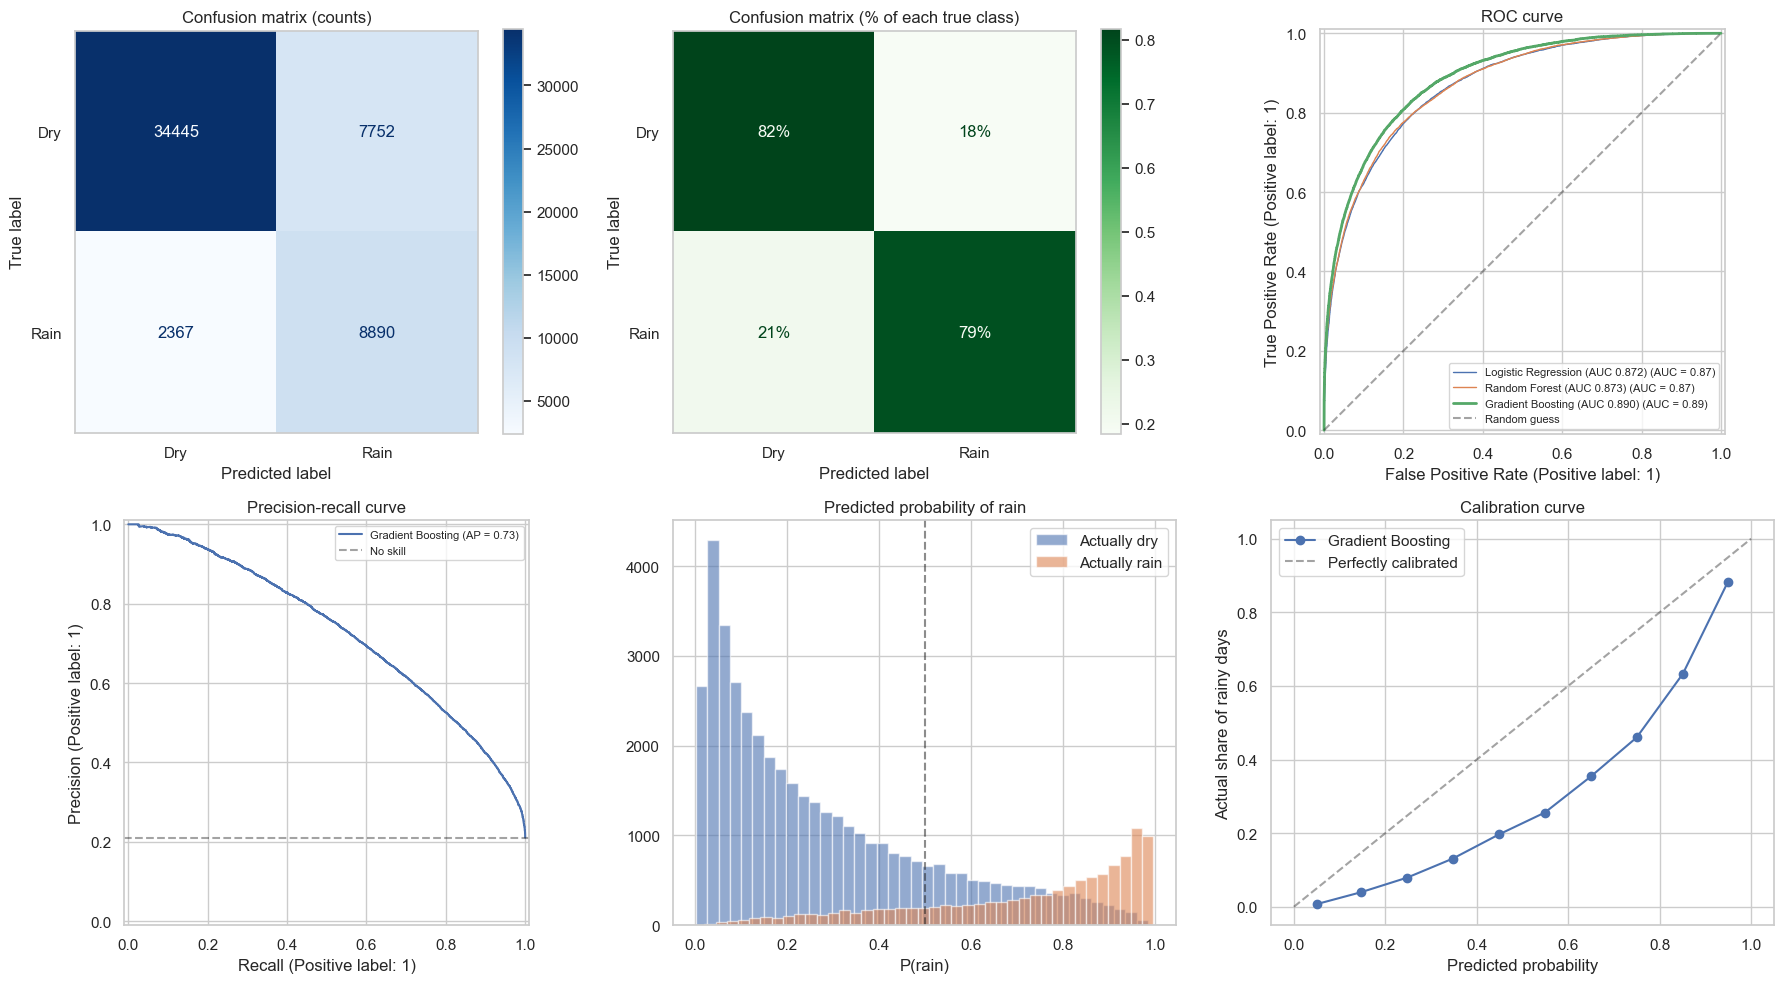

In [17]:
candidates = results.loc[~results.index.str.startswith("Baseline")]
best_name = candidates["ROC-AUC"].idxmax()
best = fitted[best_name]
print("Best model:", best_name)

proba = best.predict_proba(Xte)[:, 1]
pred = (proba >= 0.5).astype(int)
print("\n", classification_report(yte, pred, target_names=["Dry", "Rain"], digits=3))

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

ConfusionMatrixDisplay.from_predictions(yte, pred, display_labels=["Dry", "Rain"],
                                        cmap="Blues", ax=axes[0, 0])
axes[0, 0].set_title("Confusion matrix (counts)")
axes[0, 0].grid(False)

ConfusionMatrixDisplay.from_predictions(yte, pred, display_labels=["Dry", "Rain"],
                                        normalize="true", values_format=".0%",
                                        cmap="Greens", ax=axes[0, 1])
axes[0, 1].set_title("Confusion matrix (% of each true class)")
axes[0, 1].grid(False)

for name, pipe in fitted.items():
    if name.startswith("Baseline"):
        continue
    p = pipe.predict_proba(Xte)[:, 1]
    RocCurveDisplay.from_predictions(yte, p, name=f"{name} (AUC {roc_auc_score(yte, p):.3f})",
                                     ax=axes[0, 2], lw=2 if name == best_name else 1)
axes[0, 2].plot([0, 1], [0, 1], "k--", alpha=0.4, label="Random guess")
axes[0, 2].set_title("ROC curve")
axes[0, 2].legend(loc="lower right", fontsize=8)

PrecisionRecallDisplay.from_predictions(yte, proba, name=best_name, ax=axes[1, 0])
axes[1, 0].axhline(yte.mean(), color="k", linestyle="--", alpha=0.4, label="No skill")
axes[1, 0].set_title("Precision-recall curve")
axes[1, 0].legend(loc="upper right", fontsize=8)

axes[1, 1].hist(proba[yte == 0], bins=40, alpha=0.6, label="Actually dry", color="#4C72B0")
axes[1, 1].hist(proba[yte == 1], bins=40, alpha=0.6, label="Actually rain", color="#DD8452")
axes[1, 1].axvline(0.5, color="k", linestyle="--", alpha=0.5)
axes[1, 1].set_title("Predicted probability of rain")
axes[1, 1].set_xlabel("P(rain)")
axes[1, 1].legend()

frac_pos, mean_pred = calibration_curve(yte, proba, n_bins=10)
axes[1, 2].plot(mean_pred, frac_pos, "o-", label=best_name)
axes[1, 2].plot([0, 1], [0, 1], "k--", alpha=0.4, label="Perfectly calibrated")
axes[1, 2].set_title("Calibration curve")
axes[1, 2].set_xlabel("Predicted probability")
axes[1, 2].set_ylabel("Actual share of rainy days")
axes[1, 2].legend()

plt.tight_layout()
os.makedirs("../images", exist_ok=True)
plt.savefig("../images/model_evaluation.png", dpi=150, bbox_inches="tight")
plt.show()

###Choose the decision threshold

Finds the best probability cut-off for calling "rain" instead of always using 0.5, using a validation slice.A tuned cut-off can improve the balance between missed rain and false alarms.

In [18]:
val_cut = train["Date"].quantile(0.85)
tr_fit = train[train["Date"] <= val_cut]
tr_val = train[train["Date"] > val_cut]

tmp = clone(best).fit(tr_fit[X_cols], tr_fit["RainTomorrow"])
val_proba = tmp.predict_proba(tr_val[X_cols])[:, 1]

prec, rec, thr = precision_recall_curve(tr_val["RainTomorrow"], val_proba)
f1s = 2 * prec[:-1] * rec[:-1] / (prec[:-1] + rec[:-1] + 1e-9)
threshold = float(thr[f1s.argmax()])
print(f"Chosen threshold: {threshold:.2f}")

test_proba = tmp.predict_proba(Xte)[:, 1]
for label, t in [("Default 0.50", 0.5), (f"Tuned {threshold:.2f}", threshold)]:
    p = (test_proba >= t).astype(int)
    print(f"{label:14s} precision={precision_score(yte, p):.3f}  "
          f"recall={recall_score(yte, p):.3f}  F1={f1_score(yte, p):.3f}")

Chosen threshold: 0.62
Default 0.50   precision=0.527  recall=0.795  F1=0.634
Tuned 0.62     precision=0.612  recall=0.697  F1=0.652


###Feature importance

Shuffles each feature and measures how much the score drops.

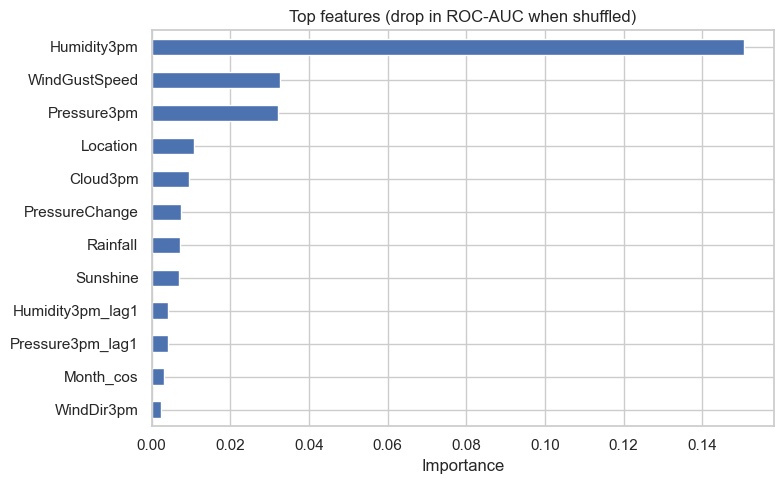

In [19]:
sample = Xte.sample(min(5000, len(Xte)), random_state=RANDOM_STATE)
imp = permutation_importance(best, sample, yte.loc[sample.index], scoring="roc_auc",
                             n_repeats=3, random_state=RANDOM_STATE, n_jobs=-1)
importance = (pd.Series(imp.importances_mean, index=X_cols)
                .sort_values(ascending=False).head(12))

importance[::-1].plot(kind="barh", figsize=(8, 5), color="#4C72B0")
plt.title("Top features (drop in ROC-AUC when shuffled)")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig("../images/feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

###Save the model and make a prediction

Saves the trained model to a file and tests it on a few recent days.

In [20]:
os.makedirs("../models", exist_ok=True)
joblib.dump({"model": best, "threshold": threshold, "features": X_cols},
            "../models/rain_model.joblib")
print("Saved to ../models/rain_model.joblib")

demo = test.tail(3)
probs = best.predict_proba(demo[X_cols])[:, 1]
for (_, row), p in zip(demo.iterrows(), probs):
    guess = "Rain" if p >= threshold else "Dry"
    actual = "Rain" if row["RainTomorrow"] == 1 else "Dry"
    print(f"{row['Location']:>12} {row['Date'].date()}  P(rain)={p:.2f}  predicted={guess}  actual={actual}")

Saved to ../models/rain_model.joblib
    Portland 2026-01-30  P(rain)=0.40  predicted=Dry  actual=Dry
  Townsville 2026-01-30  P(rain)=0.38  predicted=Dry  actual=Dry
     Woomera 2026-01-30  P(rain)=0.03  predicted=Dry  actual=Dry


In [21]:
print(list(fitted.keys()))

['Baseline (always dry)', 'Logistic Regression', 'Random Forest', 'Gradient Boosting']


In [22]:
rows = []
for name, pipe in fitted.items():
       if name.startswith("Baseline"):
           continue
       tr = roc_auc_score(ytr, pipe.predict_proba(Xtr)[:, 1])
       te = roc_auc_score(yte, pipe.predict_proba(Xte)[:, 1])
       rows.append({"Model": name, "Train ROC-AUC": tr, "Test ROC-AUC": te, "Gap": tr - te})

pd.DataFrame(rows).set_index("Model").round(3)

,Train ROC-AUC,Test ROC-AUC,Gap
Model,,,
Logistic Regression,0.877,0.872,0.006
Random Forest,0.925,0.873,0.052
Gradient Boosting,0.904,0.890,0.013
